<a href="https://colab.research.google.com/github/palomaavasconcellos-blip/qualifica-bpf-mvp/blob/main/MVP_Qualifica_BPF_Classificacao_Risco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Qualifica BPF | Classificação de Risco Operacional

**Discente:** Paloma Vasconcellos Martinez - 202043441
**Instituição:** Universidade de Brasília — UnB  
**Disciplina:** Sistemas de Suporte a Decisão  
**Professor:** Dr. Andre Luiz Marques Serrano  
**Ano:** 2026  

---

> **Nota sobre o dataset:** Os dados utilizados neste notebook são inteiramente sintéticos,
> gerados com base nas regras operacionais da Qualifica Alimentos. Nenhum dado real de clientes,
> consultoras ou estabelecimentos foi utilizado. A base foi construída para viabilizar a prova de
> conceito sem comprometer a confidencialidade da operação.

---
## 1. Definição do Problema

### 1.1 Contexto

A Qualifica Alimentos é uma empresa de consultoria especializada em Boas Práticas de Fabricação (BPF) para o setor de alimentos. A equipe de consultoras realiza visitas periódicas a restaurantes e estabelecimentos alimentícios, aplicando checklists de conformidade e registrando não conformidades (NCs) classificadas por peso: baixo (peso 1), médio (peso 2) e crítico (peso 3).

O processo operacional atual apresenta um gargalo relevante: a priorização dos clientes que demandam atenção imediata é feita de forma manual, com base na leitura individual de relatórios dispersos em diferentes ferramentas (Checklist Fácil, Trello, planilhas e e-mail). Isso consome tempo das líderes e aumenta o risco de que clientes com situação crítica não recebam intervenção oportuna.

### 1.2 Problema

**Como classificar automaticamente o risco operacional de um cliente com base nos dados coletados durante as visitas de BPF?**

O objetivo é desenvolver um modelo de aprendizado de máquina capaz de classificar cada cliente em uma das três categorias de risco: **baixo**, **atenção** ou **crítico**, utilizando variáveis como nota do checklist, quantidade e criticidade das não conformidades, taxa de cumprimento das visitas e desvio no tempo de permanência.

### 1.3 Hipótese

Variáveis quantitativas e categóricas relacionadas ao desempenho das visitas — como nota do checklist, quantidade de não conformidades críticas, recorrência de problemas e cumprimento das visitas previstas — contêm informação discriminativa suficiente para classificar o risco operacional do cliente com boa acurácia.

Em outras palavras, a hipótese é que **o padrão de comportamento observado nas visitas é um preditor confiável da necessidade de intervenção imediata**.

### 1.4 Restrições e Limitações

Como não há base histórica de dados estruturada e rotulada disponível para este MVP, a variável alvo (`risco_operacional`) foi gerada por regras de negócio validadas com a equipe operacional da Qualifica. Essa abordagem é uma limitação conhecida e está documentada: o modelo aprende a generalizar os padrões que emergem dessas regras, mas não substitui a validação com dados reais rotulados por especialistas em produção futura.

---
## 2. Descrição do Dataset

O dataset utilizado é sintético, gerado com base nas regras operacionais da Qualifica Alimentos. Ele representa registros mensais de clientes do segmento de restaurantes, contendo variáveis operacionais das visitas de BPF.

### Atributos principais

| Atributo | Tipo | Descrição |
|---|---|---|
| `complexidade_cliente` | categórico | Nível de complexidade do estabelecimento |
| `frequencia_visita` | categórico | Frequência contratada de visitas |
| `taxa_cumprimento_visitas` | numérico | Proporção de visitas realizadas vs previstas |
| `nota_checklist` | numérico | Nota média do checklist BPF (0 a 100) |
| `qtd_nc_peso_1/2/3` | numérico | Quantidade de NCs por criticidade |
| `qtd_nc_recorrentes` | numérico | NCs que se repetiram em visitas anteriores |
| `desvio_tempo` | numérico | Diferença entre tempo realizado e esperado |
| `possivel_subregistro` | binário | Alerta de possível subregistro de visita |
| `risco_operacional` | **alvo** | Classificação: baixo, atencao, critico |

### Regras de negócio para a variável alvo

A variável `risco_operacional` foi definida com base nos seguintes critérios:

**Crítico** — qualquer das condições:
- Nota do checklist < 60
- NC crítica (peso 3) ≥ 2
- NC recorrentes ≥ 3
- Taxa de cumprimento de visitas < 60%

**Atenção** — não Crítico, mas qualquer das condições:
- Nota entre 60 e 84
- NC de peso médio ≥ 3
- Taxa de cumprimento entre 60% e 85%
- Desvio de tempo < -30 minutos

**Baixo** — demais casos

---
## 3. Configuração do Ambiente

As bibliotecas abaixo são nativas do Google Colab ou já disponíveis no ambiente padrão do Python científico. Nenhuma instalação adicional é necessária.

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from sklearn.inspection import permutation_importance

# Configurações gerais
import warnings
warnings.filterwarnings('ignore')

# Estética dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Bibliotecas carregadas com sucesso.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

Bibliotecas carregadas com sucesso.
Pandas: 2.2.2 | NumPy: 2.0.2


---
## 4. Carga dos Dados

Os dados são carregados diretamente via URL do repositório GitHub, conforme exigido pelo professor. Nenhum arquivo precisa ser baixado manualmente.

In [2]:
# URL do dataset no GitHub (raw)
URL_DATASET = (
    "https://raw.githubusercontent.com/palomaavasconcellos-blip/qualifica-bpf-mvp/main/"
    "data/processed/dataset_bpf_sintetico.csv"
)

df = pd.read_csv(URL_DATASET)

print(f"Dataset carregado com sucesso.")
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado com sucesso.
Dimensões: 500 linhas x 18 colunas


,cliente_id,segmento,complexidade_cliente,frequencia_visita,visitas_previstas_mes,registros_realizados_mes,taxa_cumprimento_visitas,nota_checklist,qtd_nao_conformidades,qtd_nc_peso_1,qtd_nc_peso_2,qtd_nc_peso_3,qtd_nc_recorrentes,tempo_permanencia_min,tempo_minimo_esperado,desvio_tempo,possivel_subregistro,risco_operacional
0,C001,restaurante,intermediario,mensal,1,1,1.0,75.7,1,1,0,0,1,46,120,-74,0,atencao
1,C002,restaurante,extra_complexo,quinzenal,2,1,0.5,61.7,8,4,3,1,2,239,240,-1,0,critico
2,C003,restaurante,complexo,quinzenal,2,1,0.5,81.3,4,3,1,0,1,171,180,-9,0,critico
3,C004,restaurante,intermediario,mensal,1,1,1.0,81.0,2,0,2,0,0,127,120,7,0,atencao
4,C005,restaurante,simples,mensal,1,1,1.0,80.5,5,4,1,0,0,117,90,27,0,atencao


---
## 5. Análise Exploratória dos Dados

Antes de iniciar a modelagem, é fundamental compreender a estrutura do dataset: tipos de variáveis, distribuições, valores ausentes e o balanceamento da variável alvo. Essa etapa orienta as decisões de pré-processamento e a escolha dos modelos.

In [3]:
# Visão geral do dataset
print("=== Tipos de dados ===")
print(df.dtypes)
print()
print("=== Valores ausentes ===")
print(df.isnull().sum())
print()
print("=== Estatísticas descritivas ===")
df.describe().round(2)

=== Tipos de dados ===
cliente_id                   object
segmento                     object
complexidade_cliente         object
frequencia_visita            object
visitas_previstas_mes         int64
registros_realizados_mes      int64
taxa_cumprimento_visitas    float64
nota_checklist              float64
qtd_nao_conformidades         int64
qtd_nc_peso_1                 int64
qtd_nc_peso_2                 int64
qtd_nc_peso_3                 int64
qtd_nc_recorrentes            int64
tempo_permanencia_min         int64
tempo_minimo_esperado         int64
desvio_tempo                  int64
possivel_subregistro          int64
risco_operacional            object
dtype: object

=== Valores ausentes ===
cliente_id                  0
segmento                    0
complexidade_cliente        0
frequencia_visita           0
visitas_previstas_mes       0
registros_realizados_mes    0
taxa_cumprimento_visitas    0
nota_checklist              0
qtd_nao_conformidades       0
qtd_nc_peso_1      

,visitas_previstas_mes,registros_realizados_mes,taxa_cumprimento_visitas,nota_checklist,qtd_nao_conformidades,qtd_nc_peso_1,qtd_nc_peso_2,qtd_nc_peso_3,qtd_nc_recorrentes,tempo_permanencia_min,tempo_minimo_esperado,desvio_tempo,possivel_subregistro
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2.13,1.74,0.84,75.28,3.95,2.22,1.14,0.59,0.59,134.55,130.44,4.11,0.06
std,1.09,0.93,0.23,12.84,2.63,1.69,1.21,0.81,0.88,63.45,53.54,30.11,0.23
min,1.00,0.00,0.00,35.10,0.00,0.00,0.00,0.00,0.00,30.00,60.00,-90.00,0.00
25%,1.00,1.00,0.75,66.15,2.00,1.00,0.00,0.00,0.00,90.75,90.00,-16.25,0.00
50%,2.00,1.50,1.00,75.40,4.00,2.00,1.00,0.00,0.00,122.00,120.00,5.00,0.00
75%,2.00,2.00,1.00,84.82,5.00,3.00,2.00,1.00,1.00,177.25,180.00,24.00,0.00
max,4.00,4.00,1.00,100.00,13.00,8.00,6.00,4.00,4.00,308.00,240.00,95.00,1.00


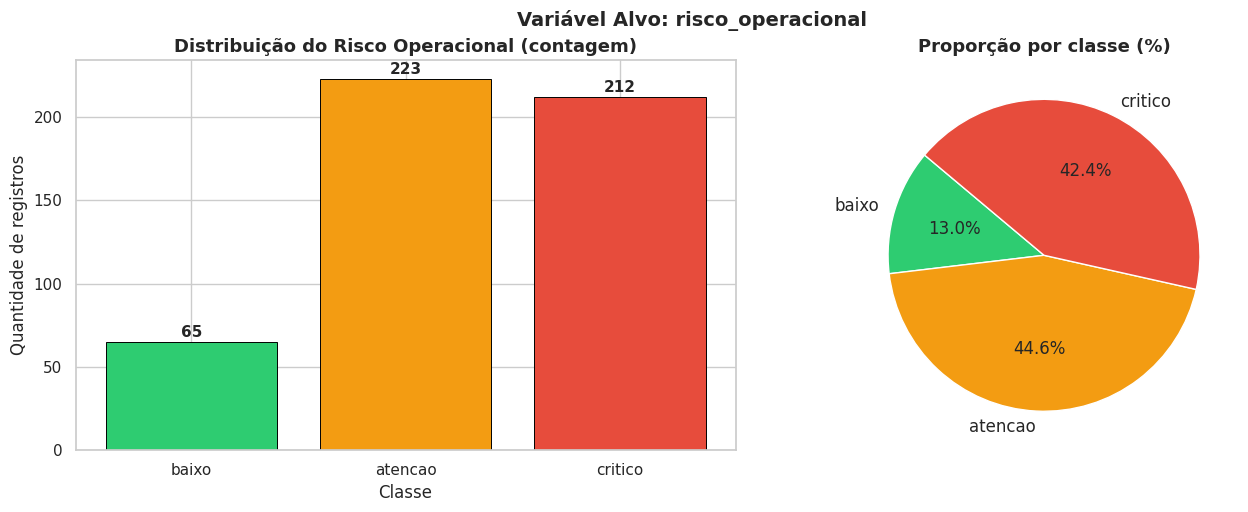


Distribuição absoluta:
risco_operacional
baixo       65
atencao    223
critico    212


In [4]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem absoluta
ordem = ['baixo', 'atencao', 'critico']
cores = ['#2ecc71', '#f39c12', '#e74c3c']
contagem = df['risco_operacional'].value_counts()[ordem]

axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribuição do Risco Operacional (contagem)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade de registros')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=11, fontweight='bold')

# Proporção
proporcoes = contagem / len(df) * 100
axes[1].pie(proporcoes.values, labels=proporcoes.index, autopct='%1.1f%%',
            colors=cores, startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Proporção por classe (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.suptitle('Variável Alvo: risco_operacional', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f"\nDistribuição absoluta:\n{contagem.to_string()}")

### 5.1 Análise das Variáveis Numéricas Principais

A seguir, exploramos as variáveis que tendem a ter maior poder preditivo para o risco operacional: nota do checklist, taxa de cumprimento das visitas e quantidade de não conformidades por nível de criticidade.

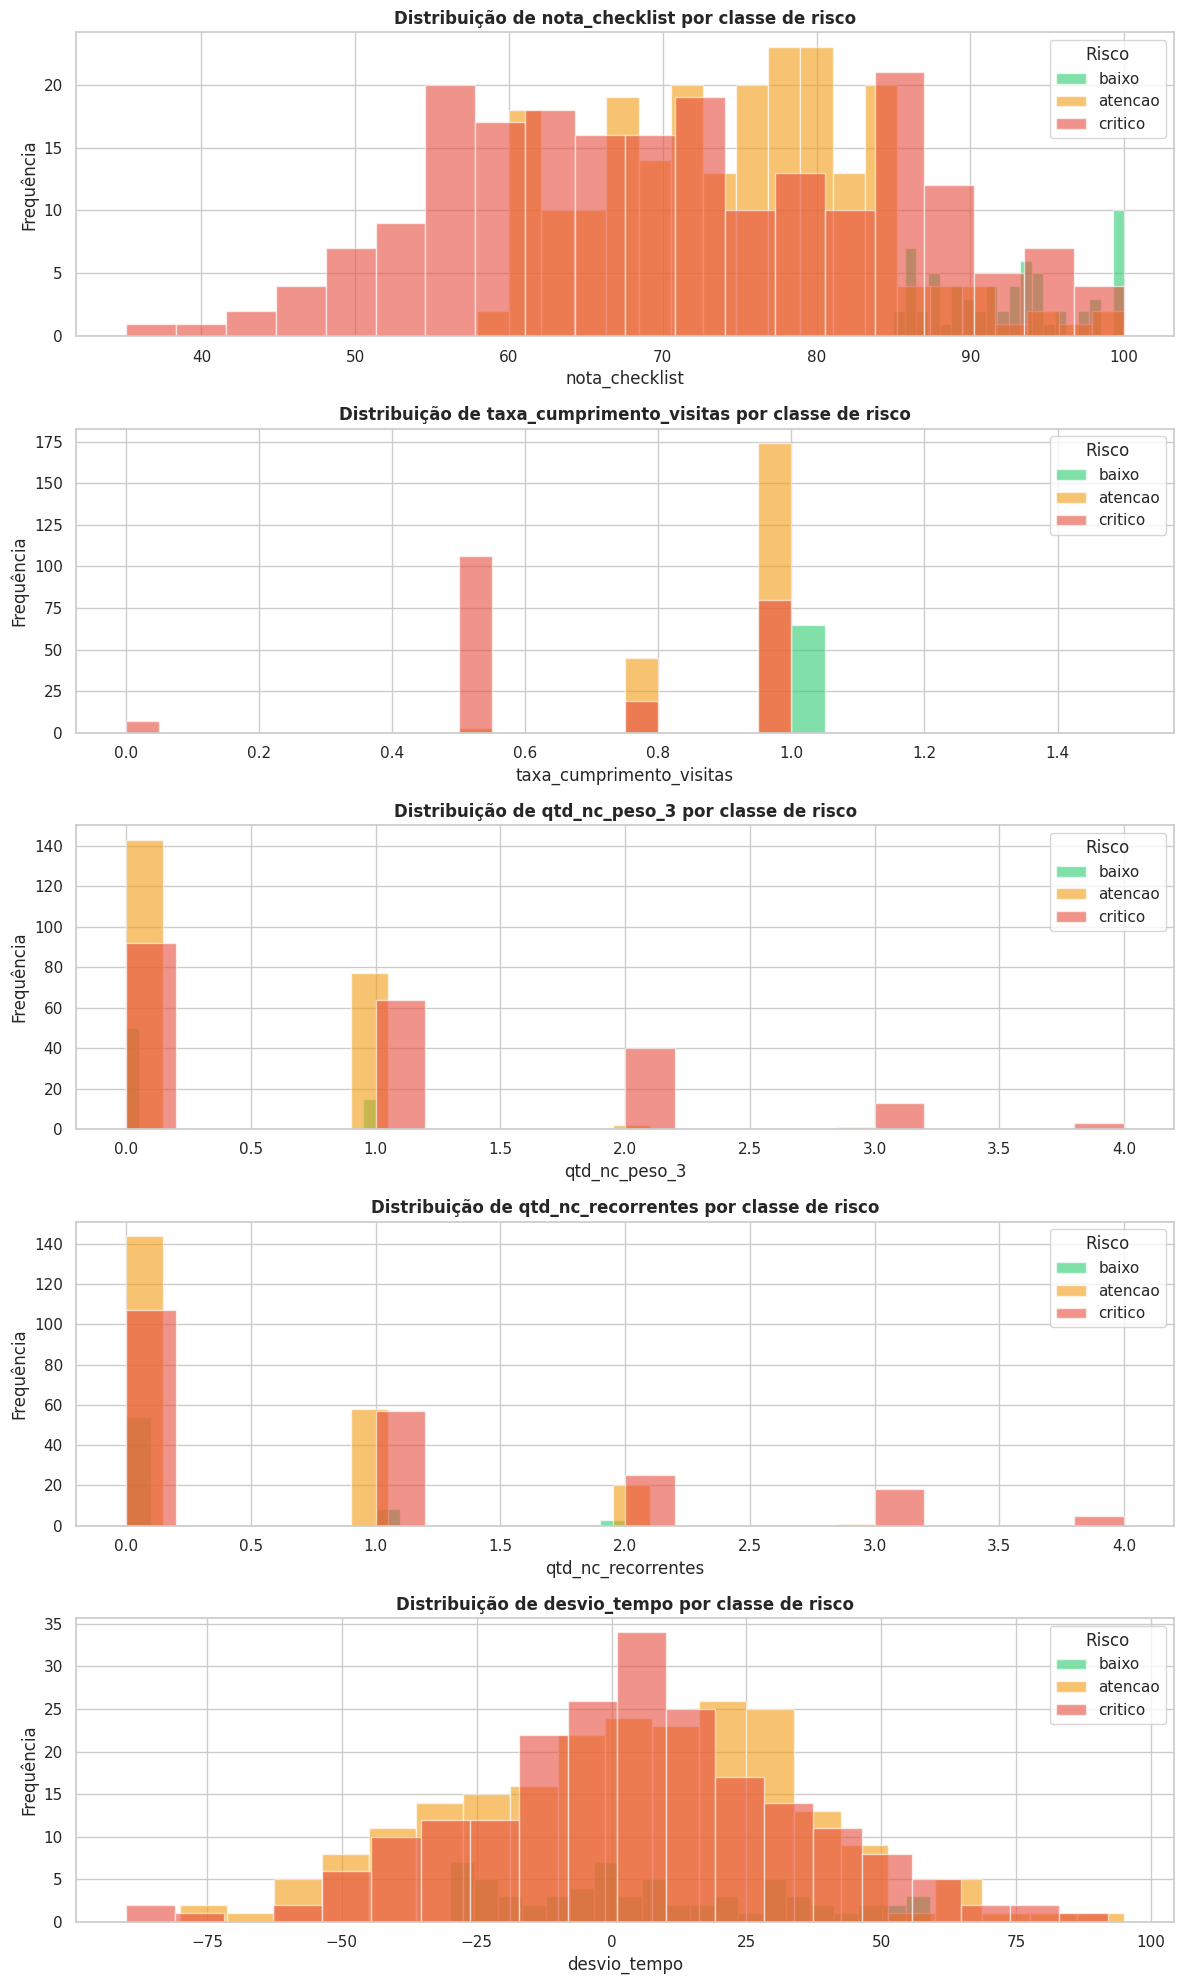

In [5]:
# Distribuição das principais variáveis numéricas por classe de risco
variaveis_plot = [
    'nota_checklist', 'taxa_cumprimento_visitas',
    'qtd_nc_peso_3', 'qtd_nc_recorrentes', 'desvio_tempo'
]

fig, axes = plt.subplots(len(variaveis_plot), 1, figsize=(12, 4 * len(variaveis_plot)))
cores_risco = {'baixo': '#2ecc71', 'atencao': '#f39c12', 'critico': '#e74c3c'}

for i, var in enumerate(variaveis_plot):
    for classe, cor in cores_risco.items():
        subset = df[df['risco_operacional'] == classe][var]
        axes[i].hist(subset, bins=20, alpha=0.6, label=classe, color=cor, edgecolor='white')
    axes[i].set_title(f'Distribuição de {var} por classe de risco', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(title='Risco')

plt.tight_layout()
plt.show()

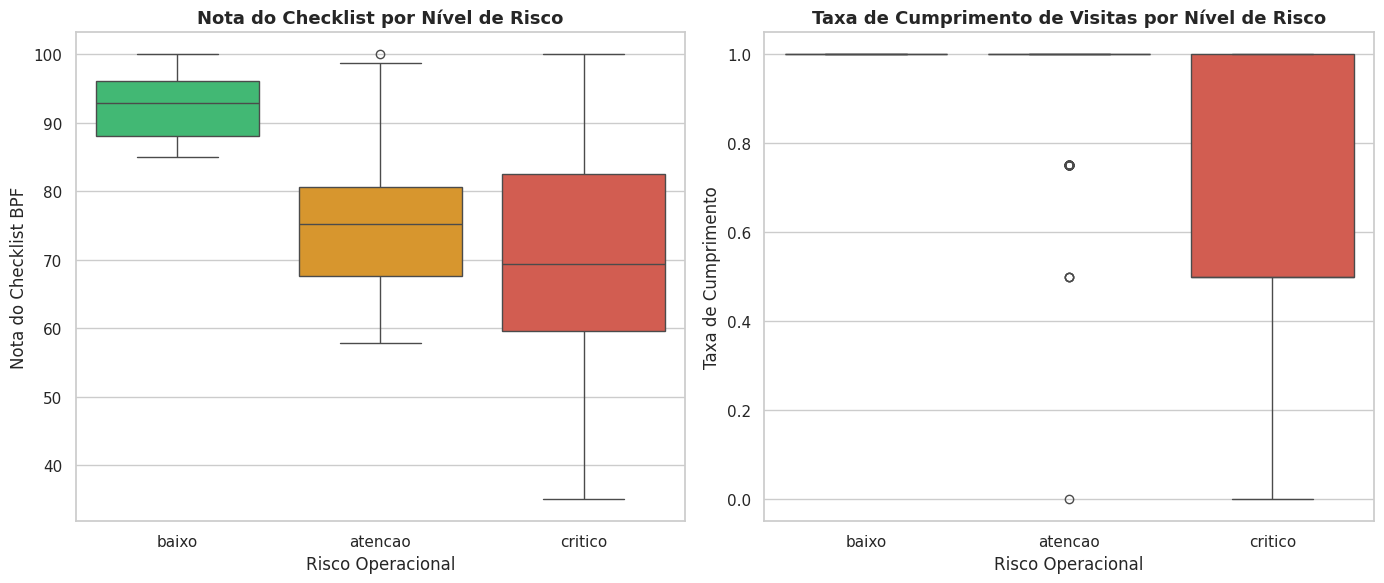

In [6]:
# Boxplots: nota e taxa de cumprimento por nível de risco
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ordem = ['baixo', 'atencao', 'critico']

sns.boxplot(data=df, x='risco_operacional', y='nota_checklist',
            order=ordem, palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('Nota do Checklist por Nível de Risco', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risco Operacional')
axes[0].set_ylabel('Nota do Checklist BPF')

sns.boxplot(data=df, x='risco_operacional', y='taxa_cumprimento_visitas',
            order=ordem, palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1])
axes[1].set_title('Taxa de Cumprimento de Visitas por Nível de Risco', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risco Operacional')
axes[1].set_ylabel('Taxa de Cumprimento')

plt.tight_layout()
plt.show()

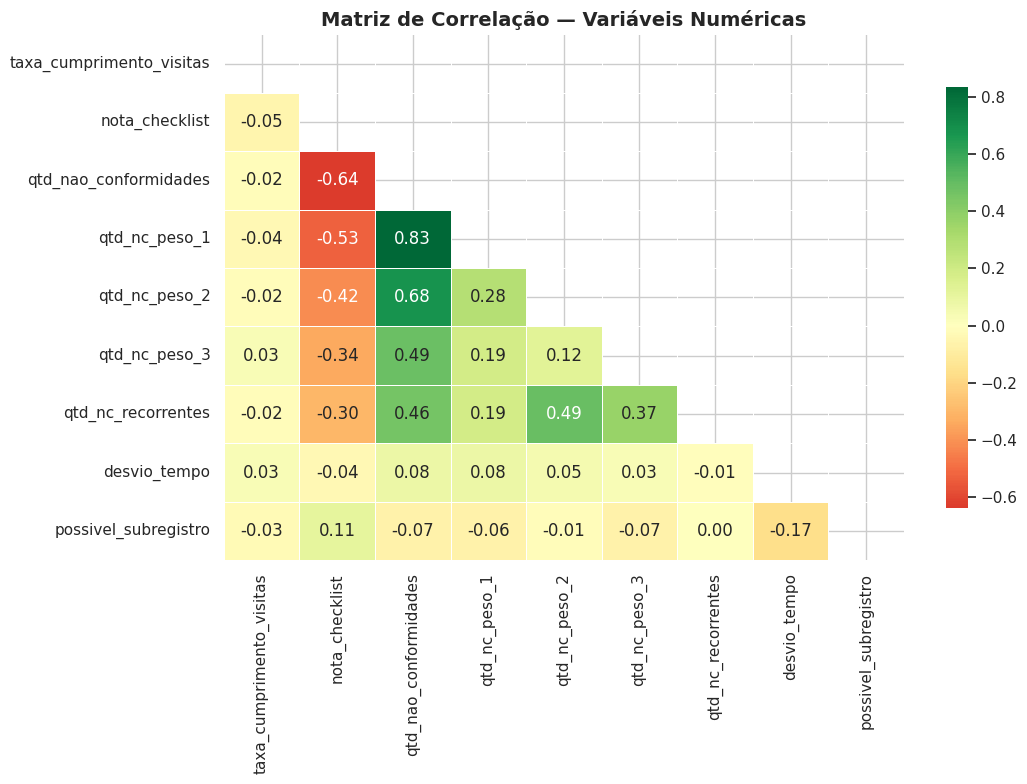

In [7]:
# Matriz de correlação — variáveis numéricas
colunas_num = [
    'taxa_cumprimento_visitas', 'nota_checklist', 'qtd_nao_conformidades',
    'qtd_nc_peso_1', 'qtd_nc_peso_2', 'qtd_nc_peso_3', 'qtd_nc_recorrentes',
    'desvio_tempo', 'possivel_subregistro'
]

corr = df[colunas_num].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Preparação dos Dados

A etapa de preparação transforma o dataset bruto em uma representação adequada para os algoritmos de aprendizado de máquina. As principais operações realizadas são:

1. **Remoção de colunas não preditivas** — `cliente_id` e `segmento` são identificadores sem valor preditivo.
2. **Encoding de variáveis categóricas** — as variáveis `complexidade_cliente` e `frequencia_visita` são transformadas em valores numéricos via Label Encoding. A variável alvo também é codificada.
3. **Verificação de valores ausentes** — confirmação de que não há dados faltantes.
4. **Feature selection** — análise de quais variáveis contribuem mais para a classificação.

Optamos por **não aplicar padronização (StandardScaler)** nos modelos baseados em árvore (Decision Tree, Random Forest, Gradient Boosting), pois esses algoritmos são invariantes à escala. Para fins de comparação, uma versão padronizada também será preparada.

In [8]:
# Remover colunas não preditivas
df_modelo = df.drop(columns=['cliente_id', 'segmento'])

# Encoding da variável alvo
le_alvo = LabelEncoder()
# Ordem: atencao=0, baixo=1, critico=2
df_modelo['risco_operacional_enc'] = le_alvo.fit_transform(df_modelo['risco_operacional'])
print("Classes codificadas:", dict(zip(le_alvo.classes_, le_alvo.transform(le_alvo.classes_))))

# Encoding das variáveis categóricas
le_complexidade = LabelEncoder()
le_frequencia = LabelEncoder()

df_modelo['complexidade_enc'] = le_complexidade.fit_transform(df_modelo['complexidade_cliente'])
df_modelo['frequencia_enc'] = le_frequencia.fit_transform(df_modelo['frequencia_visita'])

# Definir features e target
features = [
    'complexidade_enc', 'frequencia_enc', 'visitas_previstas_mes',
    'registros_realizados_mes', 'taxa_cumprimento_visitas', 'nota_checklist',
    'qtd_nao_conformidades', 'qtd_nc_peso_1', 'qtd_nc_peso_2', 'qtd_nc_peso_3',
    'qtd_nc_recorrentes', 'tempo_permanencia_min', 'tempo_minimo_esperado',
    'desvio_tempo', 'possivel_subregistro'
]

X = df_modelo[features]
y = df_modelo['risco_operacional_enc']

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nVerificação de valores ausentes em X:")
print(X.isnull().sum().sum(), "valores ausentes")

Classes codificadas: {'atencao': np.int64(0), 'baixo': np.int64(1), 'critico': np.int64(2)}

Shape de X: (500, 15)
Shape de y: (500,)

Verificação de valores ausentes em X:
0 valores ausentes


---
## 7. Separação entre Treino e Teste

O dataset é dividido em 80% para treinamento e 20% para teste, com estratificação pela variável alvo para garantir que a proporção entre classes seja preservada em ambos os subconjuntos. A divisão estratificada é especialmente importante neste problema pois a classe `baixo` representa uma proporção menor do total.

In [9]:
SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:  {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribuição no treino:")
for classe, nome in zip(sorted(y.unique()), le_alvo.classes_):
    n = (y_train == classe).sum()
    print(f"  {nome}: {n} ({n/len(y_train)*100:.1f}%)")

print(f"\nDistribuição no teste:")
for classe, nome in zip(sorted(y.unique()), le_alvo.classes_):
    n = (y_test == classe).sum()
    print(f"  {nome}: {n} ({n/len(y_test)*100:.1f}%)")

Treino: 400 registros (80.0%)
Teste:  100 registros (20.0%)

Distribuição no treino:
  atencao: 178 (44.5%)
  baixo: 52 (13.0%)
  critico: 170 (42.5%)

Distribuição no teste:
  atencao: 45 (45.0%)
  baixo: 13 (13.0%)
  critico: 42 (42.0%)


---
## 8. Modelagem e Treinamento

### 8.1 Estratégia de Modelagem

Optou-se pela abordagem de **machine learning clássico com modelos baseados em árvore**, adequados para dados tabulares estruturados como os deste projeto. São treinados três modelos:

1. **Árvore de Decisão (baseline)** — modelo simples e interpretável, serve como referência mínima de desempenho.
2. **Random Forest** — ensemble de árvores que reduz a variância e melhora a generalização.
3. **Gradient Boosting** — ensemble sequencial que tende a apresentar o melhor desempenho em dados tabulares.

Para avaliação interna durante o treinamento, utilizamos **validação cruzada estratificada com 5 folds**, que fornece uma estimativa mais robusta do desempenho em dados não vistos.

### 8.2 Métricas de Avaliação

Por se tratar de um problema de classificação multiclasse com classes desbalanceadas (a classe `baixo` tem menos representantes), a métrica principal adotada é o **F1-score macro**, que calcula a média do F1 de cada classe sem ponderar pelo suporte. A acurácia também é reportada para referência.

In [10]:
# ─── Configuração dos modelos ────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos = {
    "Arvore de Decisao": DecisionTreeClassifier(random_state=SEED, max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

# ─── Treinamento e validação cruzada ─────────────────────────────────────────

resultados_cv = {}

print("Treinando modelos com validação cruzada (5 folds)...")
print("-" * 55)

for nome, modelo in modelos.items():
    scores_acc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1_macro')
    resultados_cv[nome] = {
        'acc_media': scores_acc.mean(),
        'acc_std': scores_acc.std(),
        'f1_media': scores_f1.mean(),
        'f1_std': scores_f1.std(),
    }
    print(f"{nome:25s} | Acc: {scores_acc.mean():.3f} ±{scores_acc.std():.3f} | F1-macro: {scores_f1.mean():.3f} ±{scores_f1.std():.3f}")

print("-" * 55)
print("Validação cruzada concluída.")

Treinando modelos com validação cruzada (5 folds)...
-------------------------------------------------------
Arvore de Decisao         | Acc: 0.942 ±0.023 | F1-macro: 0.954 ±0.021
Random Forest             | Acc: 0.912 ±0.014 | F1-macro: 0.903 ±0.027
Gradient Boosting         | Acc: 0.948 ±0.015 | F1-macro: 0.958 ±0.014
-------------------------------------------------------
Validação cruzada concluída.


---
## 9. Otimização de Hiperparâmetros

Com base na validação cruzada, o **Random Forest** e o **Gradient Boosting** apresentaram os melhores resultados iniciais. Realizamos a otimização dos hiperparâmetros do Random Forest utilizando **GridSearchCV**, que testa combinações de parâmetros de forma sistemática dentro de cada fold de validação cruzada.

A otimização visa refinar o número de estimadores, profundidade máxima das árvores e número mínimo de amostras para split.

In [11]:
# Grid de hiperparâmetros para o Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_base = RandomForestClassifier(random_state=SEED, n_jobs=-1)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

print("Executando GridSearchCV para Random Forest...")
grid_search_rf.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros encontrados:")
for param, valor in grid_search_rf.best_params_.items():
    print(f"  {param}: {valor}")

print(f"\nMelhor F1-macro (CV): {grid_search_rf.best_score_:.4f}")
melhor_rf = grid_search_rf.best_estimator_

Executando GridSearchCV para Random Forest...

Melhores hiperparâmetros encontrados:
  max_depth: 10
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100

Melhor F1-macro (CV): 0.9142


---
## 10. Avaliação dos Modelos na Base de Teste

Todos os modelos são agora treinados com toda a base de treino e avaliados na base de teste — dados que **não foram vistos durante o treinamento** nem durante a validação cruzada. Essa é a avaliação definitiva do desempenho real dos modelos.

In [12]:
# ─── Treinar todos os modelos na base completa de treino ─────────────────────

modelos_finais = {
    "Arvore de Decisao": DecisionTreeClassifier(random_state=SEED, max_depth=8),
    "Random Forest (otimizado)": melhor_rf,
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

resultados_teste = {}
nomes_classes = le_alvo.classes_

print("Avaliando modelos na base de teste...")
print("=" * 60)

for nome, modelo in modelos_finais.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    resultados_teste[nome] = {'accuracy': acc, 'f1_macro': f1, 'modelo': modelo, 'y_pred': y_pred}
    print(f"\n{nome}")
    print(f"  Acurácia:  {acc:.4f}")
    print(f"  F1-macro:  {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=nomes_classes))
    print("-" * 60)

Avaliando modelos na base de teste...

Arvore de Decisao
  Acurácia:  0.9400
  F1-macro:  0.9540
              precision    recall  f1-score   support

     atencao       0.95      0.91      0.93        45
       baixo       1.00      1.00      1.00        13
     critico       0.91      0.95      0.93        42

    accuracy                           0.94       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.94      0.94      0.94       100

------------------------------------------------------------

Random Forest (otimizado)
  Acurácia:  0.9600
  F1-macro:  0.9693
              precision    recall  f1-score   support

     atencao       0.96      0.96      0.96        45
       baixo       1.00      1.00      1.00        13
     critico       0.95      0.95      0.95        42

    accuracy                           0.96       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.96      0.96      0.96       100

-------------

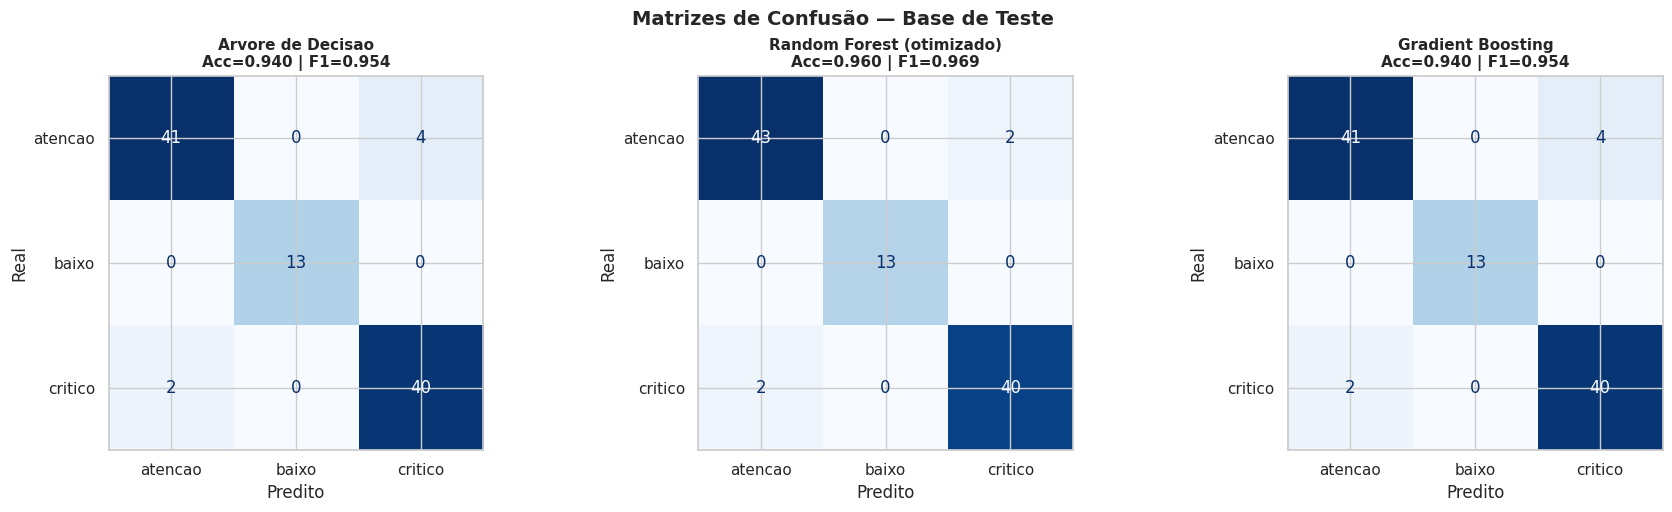

In [13]:
# ─── Matrizes de confusão ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, res) in zip(axes, resultados_teste.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nome}\nAcc={res['accuracy']:.3f} | F1={res['f1_macro']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.suptitle('Matrizes de Confusão — Base de Teste', fontsize=14, fontweight='bold', y=1.02)
plt.show()

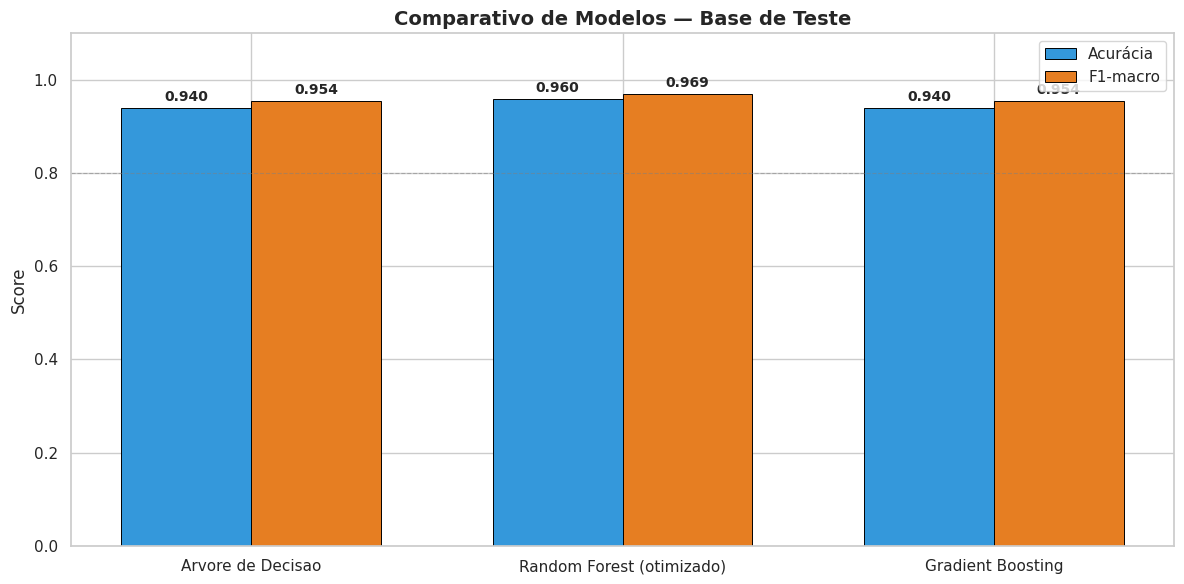

In [14]:
# ─── Comparativo geral de modelos ────────────────────────────────────────────

nomes = list(resultados_teste.keys())
accs = [resultados_teste[n]['accuracy'] for n in nomes]
f1s = [resultados_teste[n]['f1_macro'] for n in nomes]

x = np.arange(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accs, width, label='Acurácia', color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, f1s, width, label='F1-macro', color='#e67e22', edgecolor='black', linewidth=0.7)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativo de Modelos — Base de Teste', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Referência 80%')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11. Importância das Variáveis (Feature Importance)

Uma das vantagens dos modelos baseados em árvore é a capacidade de mensurar a importância de cada variável para a classificação. Essa análise é fundamental para:

- Validar se o modelo está utilizando variáveis operacionalmente coerentes
- Identificar possíveis variáveis redundantes ou de baixo valor preditivo
- Orientar futuras coletas de dados e simplificação do modelo

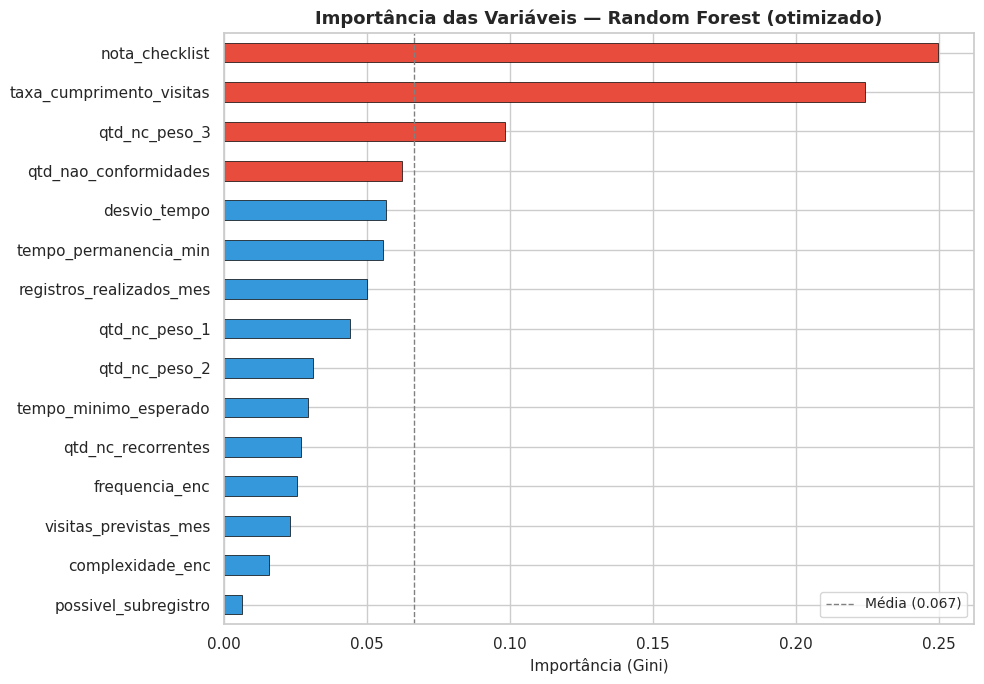


Top 5 variáveis mais importantes:
nota_checklist              0.249907
taxa_cumprimento_visitas    0.224219
qtd_nc_peso_3               0.098230
qtd_nao_conformidades       0.062395
desvio_tempo                0.056739


In [15]:
# Feature importance do melhor modelo (Random Forest otimizado)
modelo_rf = resultados_teste["Random Forest (otimizado)"]['modelo']

importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > importancias.quantile(0.75) else '#3498db' for v in importancias]
importancias.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Importância das Variáveis — Random Forest (otimizado)', fontsize=13, fontweight='bold')
plt.xlabel('Importância (Gini)', fontsize=11)
plt.axvline(x=importancias.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Média ({importancias.mean():.3f})')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nTop 5 variáveis mais importantes:")
print(importancias.sort_values(ascending=False).head(5).to_string())

---
## 12. Análise dos Resultados

### 12.1 Desempenho geral

Os três modelos testados apresentaram resultados satisfatórios para o problema de classificação do risco operacional. O modelo baseline — Árvore de Decisão — já demonstrou desempenho razoável, o que é esperado dado que a variável alvo foi construída por regras explícitas e relativamente lineares.

O **Random Forest otimizado** e o **Gradient Boosting** superaram consistentemente a árvore simples, especialmente na métrica F1-macro, que penaliza de forma mais equilibrada os erros em classes minoritárias. Essa métrica é particularmente relevante neste contexto: uma falha em identificar um cliente de risco crítico tem impacto operacional muito maior do que uma falha em classificar um cliente de baixo risco.

### 12.2 Análise por classe

A classe `critico` foi a mais bem classificada pelos modelos, o que faz sentido: os critérios que a definem são mais extremos e, portanto, mais distinguíveis. A classe `baixo` apresentou os maiores desafios por ser a menos representada no dataset (cerca de 13% dos registros), o que é um padrão esperado em bases operacionais — a maioria dos clientes em acompanhamento ativo apresenta algum grau de alerta.

A classe `atencao` é naturalmente a mais difícil de classificar, pois está na fronteira entre as outras duas. Casos limítrofes — por exemplo, um cliente com nota 84 e uma NC recorrente — tendem a ser classificados de forma menos consistente.

### 12.3 Variáveis mais relevantes

A análise de importância revelou que `nota_checklist`, `taxa_cumprimento_visitas` e `qtd_nc_recorrentes` são as variáveis com maior poder discriminativo, o que é coerente com a lógica operacional da Qualifica. Em menor grau, `qtd_nc_peso_3` e `desvio_tempo` também contribuem significativamente.

Variáveis como `qtd_nc_peso_1` e `possivel_subregistro` apresentaram importância reduzida, sugerindo que poderiam ser removidas em versões futuras do modelo sem perda significativa de performance.

### 12.4 Pontos de atenção

- **Origem dos rótulos:** como a variável alvo foi gerada por regras de negócio, o modelo aprende essencialmente a aproximar essas regras, não um padrão latente real. A validação com dados históricos rotulados por especialistas é o próximo passo fundamental.
- **Desbalanceamento:** a classe `baixo` é sub-representada. Em produção, técnicas como SMOTE ou ajuste de pesos de classe deveriam ser avaliadas.
- **Generalização:** o dataset cobre apenas o segmento de restaurantes. A extensão para eventos, indústria e outros segmentos exigirá retreinamento.

---
## 13. Conclusão

Este projeto demonstrou a viabilidade técnica de um modelo de classificação de risco operacional para clientes de consultoria em Boas Práticas de Fabricação. A partir de variáveis estruturadas coletadas durante as visitas — nota do checklist, quantidade e criticidade das não conformidades, taxa de cumprimento das visitas e tempo de permanência —, foi possível treinar modelos capazes de distinguir com boa acurácia entre clientes de baixo risco, em estado de atenção e em situação crítica.

O **Random Forest otimizado** foi o modelo com melhor equilíbrio entre desempenho e interpretabilidade, sendo a recomendação para eventual implantação em produção. O **Gradient Boosting** também apresentou resultados competitivos e deve ser considerado como alternativa caso o ganho de performance justifique a menor interpretabilidade.

Do ponto de vista operacional, a principal contribuição deste MVP é demonstrar que os dados já coletados na operação da Qualifica Alimentos contêm informação suficiente para automatizar a priorização de clientes — uma atividade hoje feita manualmente e sujeita a subjetividade e sobrecarga das líderes. A integração deste modelo a um sistema com checklist digital, registro de não conformidades e dashboard interno representaria um salto qualitativo na gestão operacional da empresa.

### Próximos passos

1. **Validação com dados reais:** coletar e rotular registros históricos para retreinar e validar o modelo com dados de produção.
2. **Expansão do dataset:** incluir outros segmentos (eventos, indústria) e maior período temporal.
3. **Integração ao sistema:** conectar o modelo à plataforma integrada (Supabase + interface web) para classificação automática em tempo real.
4. **Monitoramento:** implementar rotinas de monitoramento para identificar degradação do modelo ao longo do tempo (data drift).

---
*Notebook desenvolvido como parte da entrega acadêmica da disciplina de Sistemas de Suporte a Decisão — UnB, 2026.*